In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ultimate_student_productivity_dataset_5000.csv')
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [3]:
df.drop(columns=['productivity_score', 'gaming_hours', 'social_media_hours', 'gender', 'internet_quality'], inplace=True)
df.head()

,student_id,age,academic_level,study_hours,self_study_hours,online_classes_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,exam_score
0,1,18,High School,7.64,1.56,2.20,6.52,6.47,81,38,1,0,10,43.05,31.77,50.16
1,2,18,High School,2.21,2.22,2.10,5.97,6.05,111,339,0,0,3,15.92,37.00,1.00
2,3,22,High School,3.45,0.00,0.29,8.39,7.62,68,266,0,1,8,27.39,34.37,18.30
3,4,17,High School,5.75,2.08,3.01,6.31,11.67,113,480,1,1,3,22.31,77.31,9.37
4,5,19,High School,6.83,1.72,3.33,8.01,10.02,121,24,1,0,8,38.11,39.53,27.81


In [4]:
df.isnull().sum()

student_id              0
age                     0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
mental_health_score     0
focus_index             0
burnout_level           0
exam_score              0
dtype: int64

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   academic_level        5000 non-null   object 
 3   study_hours           5000 non-null   float64
 4   self_study_hours      5000 non-null   float64
 5   online_classes_hours  5000 non-null   float64
 6   sleep_hours           5000 non-null   float64
 7   screen_time_hours     5000 non-null   float64
 8   exercise_minutes      5000 non-null   int64  
 9   caffeine_intake_mg    5000 non-null   int64  
 10  part_time_job         5000 non-null   int64  
 11  upcoming_deadline     5000 non-null   int64  
 12  mental_health_score   5000 non-null   int64  
 13  focus_index           5000 non-null   float64
 14  burnout_level         5000 non-null   float64
 15  exam_score           

In [6]:
# df['gender'].unique()

In [7]:
df['academic_level'].unique()

array(['High School', 'Undergraduate', 'Postgraduate'], dtype=object)

In [8]:
# df['internet_quality'].unique()

In [9]:
level_map={
    'High School': 1,
    'Undergraduate': 2,
    'Postgraduate': 3,
}

df['academic_level'] = df['academic_level'].map(level_map)

In [10]:
df.head()

,student_id,age,academic_level,study_hours,self_study_hours,online_classes_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,exam_score
0,1,18,1,7.64,1.56,2.20,6.52,6.47,81,38,1,0,10,43.05,31.77,50.16
1,2,18,1,2.21,2.22,2.10,5.97,6.05,111,339,0,0,3,15.92,37.00,1.00
2,3,22,1,3.45,0.00,0.29,8.39,7.62,68,266,0,1,8,27.39,34.37,18.30
3,4,17,1,5.75,2.08,3.01,6.31,11.67,113,480,1,1,3,22.31,77.31,9.37
4,5,19,1,6.83,1.72,3.33,8.01,10.02,121,24,1,0,8,38.11,39.53,27.81


In [11]:
df.corr()['burnout_level'].sort_values(ascending=False)

burnout_level           1.000000
upcoming_deadline       0.510612
part_time_job           0.372089
screen_time_hours       0.340652
caffeine_intake_mg      0.197278
student_id              0.030547
academic_level          0.008575
mental_health_score     0.008399
self_study_hours        0.002670
study_hours            -0.000811
age                    -0.013559
online_classes_hours   -0.021204
focus_index            -0.075425
exercise_minutes       -0.157311
exam_score             -0.407808
sleep_hours            -0.492935
Name: burnout_level, dtype: float64

In [12]:
X = df[[
    'upcoming_deadline',
    'sleep_hours',
    'part_time_job',
    'screen_time_hours',
    'exercise_minutes',
    'caffeine_intake_mg'
]]

y = df['burnout_level']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print(X_train.shape)
print(X_test.shape)


(4000, 6)
(1000, 6)


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred = model.predict(X_test_scaled)

In [18]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)


MSE  : 34.16478059989927
RMSE : 5.845064636075402
R2   : 0.8268804217190818


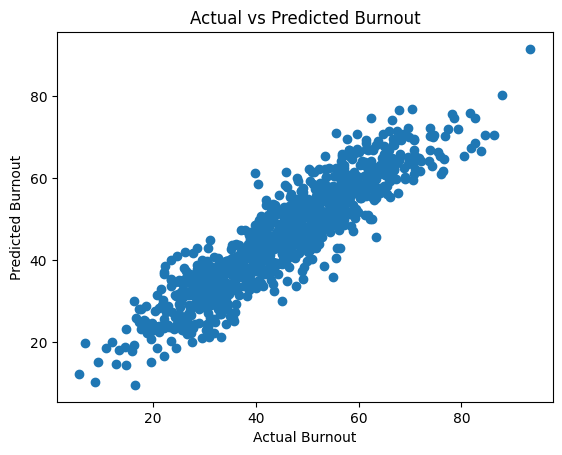

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Burnout")
plt.ylabel("Predicted Burnout")
plt.title("Actual vs Predicted Burnout")
plt.show()


In [20]:
import joblib

joblib.dump(model, "burnout_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']